
# Project Introduction: Analyzing Biomarkers and Risk Factors for Chronic Kidney Disease (CKD) Prevention

## Project Aim
The primary goal of this project is to perform **Exploratory Data Analysis (EDA)** to evaluate the effectiveness of various biological markers and some risk factors in diagnosing and monitoring Chronic Kidney Disease (CKD).

---

## Global Context and Clinical Importance 🌍
Chronic Kidney Disease is a mounting global health crisis, currently affecting approximately **850 million people** worldwide. Its impact is characterized by the following statistics:

* **Mortality Trend:** It is the **3rd fastest-growing** cause of death globally.
* **Future Projections:** By 2040, CKD is expected to be the **5th leading cause** of years of life lost (YLL).
* **The "Silent" Disease:** In resource-limited settings, up to **90% of individuals** are unaware of their condition until it reaches advanced, symptomatic stages.

Early detection via biomarkers is the only effective strategy to initiate intervention before irreversible damage occurs.

---

## Dataset Overview 📊
This study utilizes a health record dataset consisting of **1,659 patients** diagnosed with CKD.

> **Note on Data Integrity:** This is a **synthetic dataset** generated for educational purposes. While the variables mirror real-world clinical parameters, the statistical correlations may not carry clinical significance. It is intended primarily for testing EDA workflows and data visualization techniques.

### Data Domains and Variables 🧪
| Domain | Variables Included |
| :--- | :--- |
| **Demographics** | Age (20–90 years), Gender, Ethnicity, Socioeconomic Status |
| **Lifestyle Factors** | BMI ($15–40 kg/m^2$), Smoking status, Alcohol, Physical Activity, Diet/Sleep Quality |
| **Medical History** | Family history of CKD, Hypertension, Diabetes, History of UTIs or AKI |
| **Clinical Metrics** | Systolic/Diastolic BP, Fasting Blood Sugar, and HbA1c |

---

## Key Biomarkers in CKD Diagnosis 🧬
Biomarkers are measurable indicators of the severity or presence of a disease state. In this analysis, we focus on four primary indicators:



### 1. Glomerular Filtration Rate (GFR) 🔍
GFR is widely considered the "gold standard" for measuring overall kidney function. It estimates how much blood passes through the glomeruli (tiny filters in the kidneys) each minute. 
* **Normal Range:** Usually above $90 mL/min/1.73m^2$.

### 2. Serum Creatinine 🩸
Creatinine is a waste product generated by muscle metabolism. Because the kidneys are responsible for filtering creatinine out of the blood, elevated levels in a blood test typically indicate impaired kidney function. It is a primary input used to calculate the GFR.

### 3. Urine Albumin-to-Creatinine Ratio (ACR) 🧪
ACR is used to identify **albuminuria** (excess protein in the urine). 
* **Significance:** While GFR measures *function*, ACR measures *damage*. 
* High levels of albumin in the urine suggest that the kidney's filters have become "leaky," often the first sign of kidney disease in patients with diabetes or hypertension.

### 4. Blood Urea Nitrogen (BUN)
BUN measures the amount of nitrogen in your blood that comes from the waste product urea. This helps determine how well the kidneys and liver are functioning.

### 5. Proteinuria (Urine Protein) 🧪
Proteinuria is the presence of excess proteins in the urine. It serves as a primary indicator of **glomerular injury**. In clinical practice, we categorize CKD not just by GFR (Stage 1–5), but also by the "A" grade (Albuminuria/Proteinuria grade), which helps determine the risk of cardiovascular events and kidney failure progression.



#### Proteinuria vs. Albuminuria
While often used interchangeably in casual clinical discussion, there is a technical distinction:
* **Albuminuria:** Refers specifically to the leakage of **albumin**, the most common protein in the blood. This is what the **ACR (Albumin-to-Creatinine Ratio)** measures.
* **Proteinuria:** A broader term that includes albumin plus all other types of proteins that might be present in the urine.

#### The Path to Early Detection
The interplay between functional biomarkers like GFR and structural indicators like Proteinuria and ACR forms the backbone of modern renal diagnostics. While GFR provides a snapshot of current kidney efficiency, the presence of albumin or protein in the urine often serves as the "canary in the coal mine," signaling damage long before the patient becomes symptomatic.

In [1]:
#pip install openpyxl

## Data Importation, Cleaning, and Exploration

In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Load the Excel file
ckd_df = pd.read_excel('CKD Transformed Data.xlsx')

# View the first few rows
ckd_df.head()

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,MuscleCramps,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis
0,1,71,Male,Caucasian,Low,Bachelor's,31.069414,Yes,5.128112,1.676220,...,4.518513,7.556302,76.076800,No,No,Poor,1.018824,4.966808,9.871449,Yes
1,2,34,Male,Caucasian,Middle,Higher,29.692119,Yes,18.609552,8.377574,...,2.202222,6.836766,40.128498,No,No,Good,3.923538,8.189275,7.161765,Yes
2,3,80,Female,Africa American,Low,High School,37.394822,Yes,11.882429,9.607401,...,5.967271,2.144722,92.872842,No,Yes,Poor,1.429906,7.624028,7.354632,Yes
3,4,40,Male,Asian,Low,High School,31.329680,No,16.020165,0.408871,...,2.176387,7.077188,90.080321,No,No,Good,3.226416,3.282688,6.629587,Yes
4,5,43,Male,Africa American,Middle,Bachelor's,23.726311,No,7.944146,0.780319,...,6.800993,3.553118,5.258372,No,No,Poor,0.285466,3.849498,1.437385,Yes


In [4]:
# Getting information about the DataFrame, including data types and non-null counts
ckd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PatientID                      1659 non-null   int64  
 1   Age                            1659 non-null   int64  
 2   Gender                         1659 non-null   object 
 3   Ethnicity                      1659 non-null   object 
 4   SocioeconomicStatus            1659 non-null   object 
 5   EducationLevel                 1479 non-null   object 
 6   BMI                            1659 non-null   float64
 7   Smoking                        1659 non-null   object 
 8   AlcoholConsumption             1659 non-null   float64
 9   PhysicalActivity               1659 non-null   float64
 10  DietQuality                    1659 non-null   float64
 11  SleepQuality                   1659 non-null   float64
 12  FamilyHistoryKidneyDisease     1659 non-null   o

In [5]:
# summarizing the DataFrame to get statistical insights about the numerical columns
ckd_df.describe()

,PatientID,Age,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,SystolicBP,DiastolicBP,FastingBloodSugar,...,CholesterolTriglycerides,NSAIDsUse,FatigueLevels,NauseaVomiting,MuscleCramps,Itching,QualityOfLifeScore,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy
count,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,...,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000
mean,830.000000,54.441230,27.620049,9.969831,5.024247,5.028544,6.942324,134.392405,89.313442,132.529429,...,224.804603,5.011715,5.016697,3.482121,3.525510,5.054869,49.730659,2.000336,4.947788,5.144973
std,479.056364,20.549757,7.288670,5.798787,2.866274,2.865777,1.704159,25.767794,17.354479,36.563035,...,100.321757,2.869813,2.896311,1.986292,2.026131,2.880460,27.827593,1.141635,2.869959,2.901138
min,1.000000,20.000000,15.033888,0.021740,0.001186,0.002407,4.001053,90.000000,60.000000,70.044768,...,50.267668,0.000469,0.015194,0.005171,0.006327,0.013697,0.087256,0.001082,0.005392,0.004436
25%,415.500000,36.000000,21.471449,5.051156,2.555038,2.558443,5.487083,113.000000,75.000000,100.504503,...,140.235507,2.619890,2.464695,1.750661,1.820793,2.532867,26.991708,1.005802,2.498119,2.569561
50%,830.000000,54.000000,27.652077,9.951503,5.072395,4.989810,6.933255,134.000000,89.000000,131.478423,...,226.466365,5.078511,5.117247,3.519894,3.572522,5.087086,48.970075,2.040635,4.974069,5.182949
75%,1244.500000,72.000000,34.015849,14.967100,7.460563,7.428290,8.346298,157.000000,104.000000,163.108151,...,309.782788,7.485980,7.565993,5.253156,5.254956,7.552093,73.913997,2.947213,7.499783,7.733253
max,1659.000000,90.000000,39.993532,19.992713,9.998167,9.998927,9.984197,179.000000,119.000000,199.960429,...,399.919138,9.999397,9.988238,6.997332,6.984636,9.998313,99.987510,3.999469,9.992345,9.993754


In [6]:
# Checking for missing values in the DataFrame
ckd_df.isnull().sum()

PatientID                          0
Age                                0
Gender                             0
Ethnicity                          0
SocioeconomicStatus                0
EducationLevel                   180
BMI                                0
Smoking                            0
AlcoholConsumption                 0
PhysicalActivity                   0
DietQuality                        0
SleepQuality                       0
FamilyHistoryKidneyDisease         0
FamilyHistoryHypertension          0
FamilyHistoryDiabetes              0
PreviousAcuteKidneyInjury          0
UrinaryTractInfections             0
SystolicBP                         0
DiastolicBP                        0
FastingBloodSugar                  0
HbA1c                              0
SerumCreatinine                    0
BUNLevels                          0
GFR                                0
ProteinInUrine                     0
ACR                                0
SerumElectrolytesSodium            0
S

### ❓ Null Values in Educational Level

The dataset has been transformed and cleaned already using **Excel** and **Power Query** 🛠️. 

##### 🤔 Why do we still have null values?

Some patients have **"None"** as their educational level, signifying that they have no formal education 🚫🏫.

##### 🔍 Let's see if that is where the null is coming from

In [7]:
# Count how many patients are in the "None" category for their Educational level
none_education_count = ckd_df[ckd_df['EducationLevel'] == 'None']
count = len(none_education_count)
print(f"Number of patients with 'None' education level: {count}")

Number of patients with 'None' education level: 0


##### This is not possible

Let's look deeper

In [8]:
ckd_df.head(40)

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,MuscleCramps,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis
0,1,71,Male,Caucasian,Low,Bachelor's,31.069414,Yes,5.128112,1.676220,...,4.518513,7.556302,76.076800,No,No,Poor,1.018824,4.966808,9.871449,Yes
1,2,34,Male,Caucasian,Middle,Higher,29.692119,Yes,18.609552,8.377574,...,2.202222,6.836766,40.128498,No,No,Good,3.923538,8.189275,7.161765,Yes
2,3,80,Female,Africa American,Low,High School,37.394822,Yes,11.882429,9.607401,...,5.967271,2.144722,92.872842,No,Yes,Poor,1.429906,7.624028,7.354632,Yes
3,4,40,Male,Asian,Low,High School,31.329680,No,16.020165,0.408871,...,2.176387,7.077188,90.080321,No,No,Good,3.226416,3.282688,6.629587,Yes
4,5,43,Male,Africa American,Middle,Bachelor's,23.726311,No,7.944146,0.780319,...,6.800993,3.553118,5.258372,No,No,Poor,0.285466,3.849498,1.437385,Yes
5,6,22,Male,Caucasian,Low,High School,39.155643,No,4.243608,8.847245,...,3.344124,8.685695,12.794110,No,No,Good,0.358613,5.766704,2.066944,Yes
6,7,41,Male,Africa American,Low,High School,35.040487,No,18.224708,8.155523,...,6.672729,1.995016,38.723030,No,No,Poor,2.744605,5.515760,3.856676,Yes
7,8,72,Female,Caucasian,Middle,Higher,30.760440,Yes,18.662717,6.179345,...,1.285188,2.178408,92.939765,No,No,Good,1.828836,8.620466,9.954670,No
8,9,21,Male,Africa American,Low,Bachelor's,22.323130,No,9.951503,9.449652,...,0.079790,9.605863,84.420517,No,No,Poor,3.521973,4.724738,6.725741,Yes
9,10,49,Male,others,Low,High School,24.338507,No,0.129900,6.464306,...,1.372919,5.170201,4.776171,No,No,Good,3.448881,8.935090,4.423802,Yes


##### Ahhh it was stored as NaN

In [9]:
# Count how many patients are in the "NaN" category for their Educational level
nan_count = ckd_df['EducationLevel'].isna().sum()

print(f"Number of NaN values: {nan_count}")

Number of NaN values: 180


In [10]:
# See unique category in Education Level
unique_education_levels = ckd_df['EducationLevel'].unique()
print("Unique Education Levels:", unique_education_levels)

Unique Education Levels: ["Bachelor's" 'Higher' 'High School' nan]


In [11]:
# Replace all NaN values in the 'Education' column with 'No Formal Education'
ckd_df['EducationLevel'] = ckd_df['EducationLevel'].fillna('No Formal Education')

In [12]:
# See the new unique category in Education Level
unique_education_levels_2 = ckd_df['EducationLevel'].unique()
print("Unique Education Levels:", unique_education_levels_2)

Unique Education Levels: ["Bachelor's" 'Higher' 'High School' 'No Formal Education']


In [13]:
# checking for duplicates in the DataFrame
ckd_df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis

### A quick look at the distribution of the numerical column

In [14]:
# Selecting only the numerical columns from the DataFrame for further analysis
ckd_numerical = ckd_df.select_dtypes(include=[np.number])

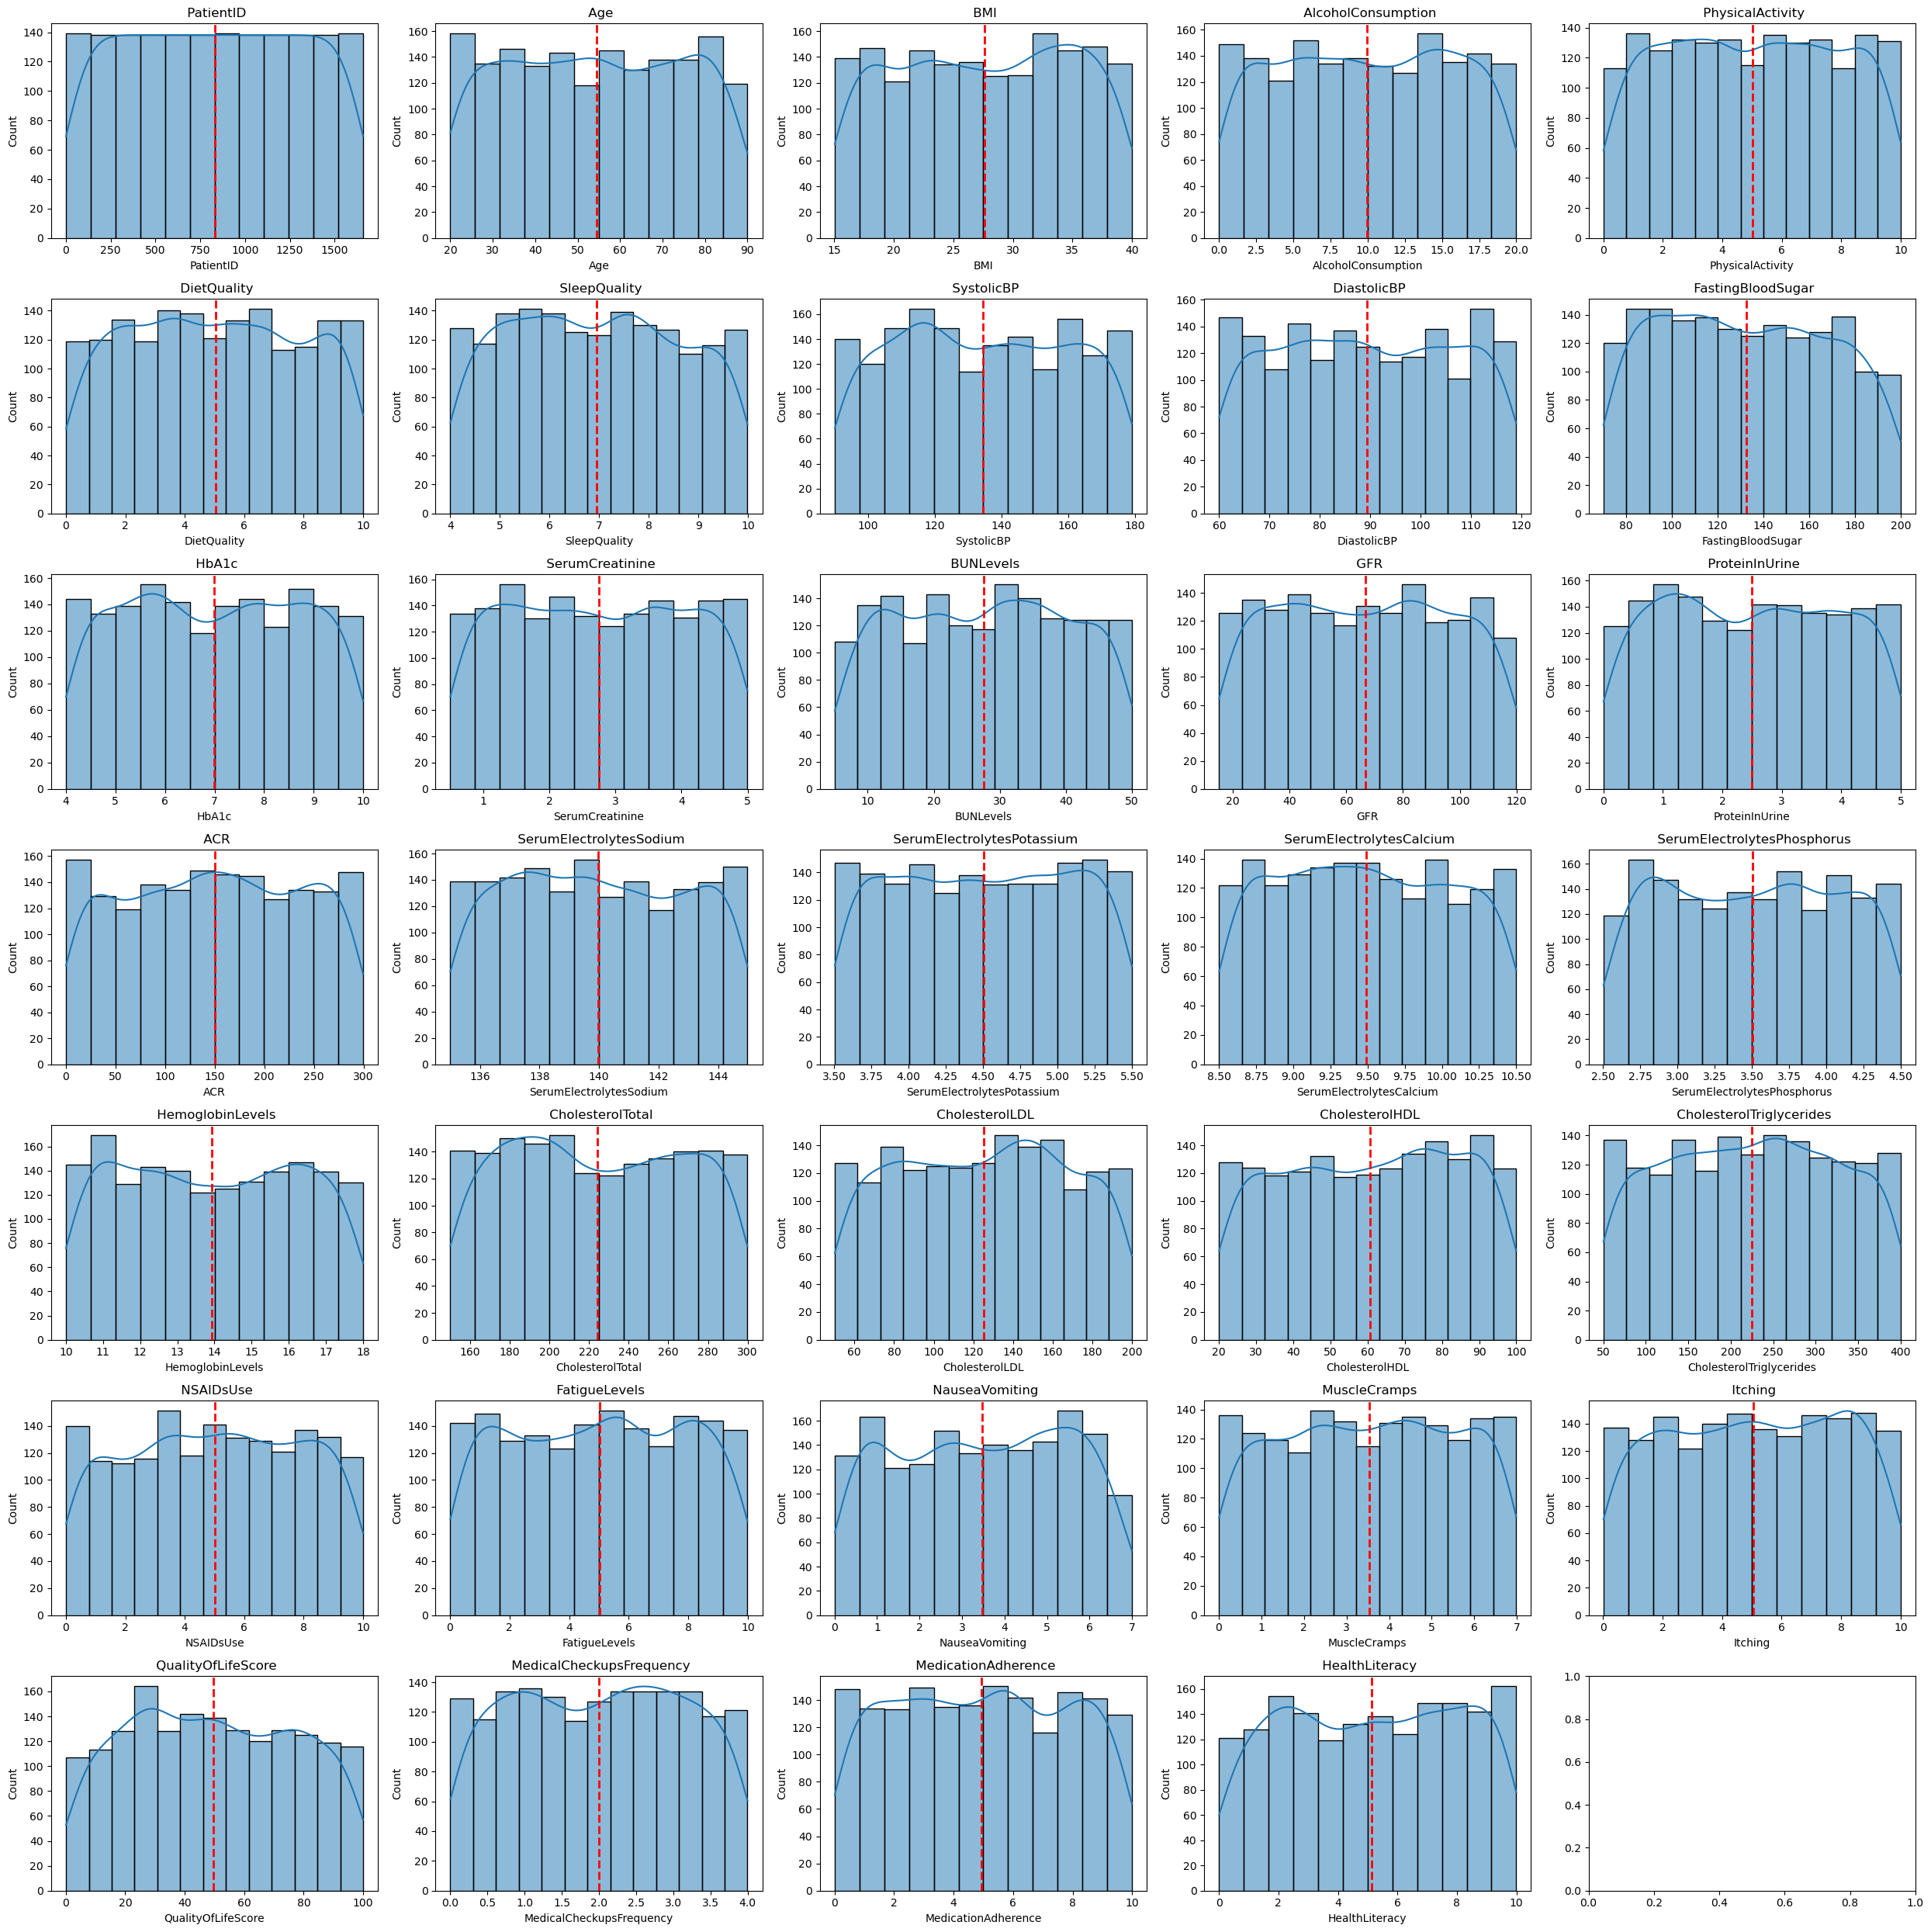

In [15]:
# Setting up a 6x9 grid of plots
fig, axes = plt.subplots(7, 5, figsize=(25, 25))  # Adjust the figure size as needed
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Plotting a KDE for each column in its respective subplot
for i, column in enumerate(ckd_numerical.columns):
    sns.histplot(ckd_numerical[column], ax=axes[i], kde=True)
    axes[i].set_title(f' {column}')

    #Add vertical line for mean
    mean_val = ckd_numerical[column].mean()
    axes[i].axvline(mean_val, color='red', linestyle='dashed', linewidth=2)



#  Adjust layout so plots don’t overlap
plt.tight_layout()
plt.show()

##### The uniform distribution of all the columns mirrors the fact that the dataset is synthetic

### Which biomaker diagnosed CKD better?

C:\Users\rosea\AppData\Local\Temp\ipykernel_3112\2503252738.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='Diagnosis', y=marker, data=ckd_df, palette='Set2')
C:\Users\rosea\AppData\Local\Temp\ipykernel_3112\2503252738.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='Diagnosis', y=marker, data=ckd_df, palette='Set2')
C:\Users\rosea\AppData\Local\Temp\ipykernel_3112\2503252738.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='Diagnosis', y=marker, data=ckd_df, palette='Set2')
C:\Users\r

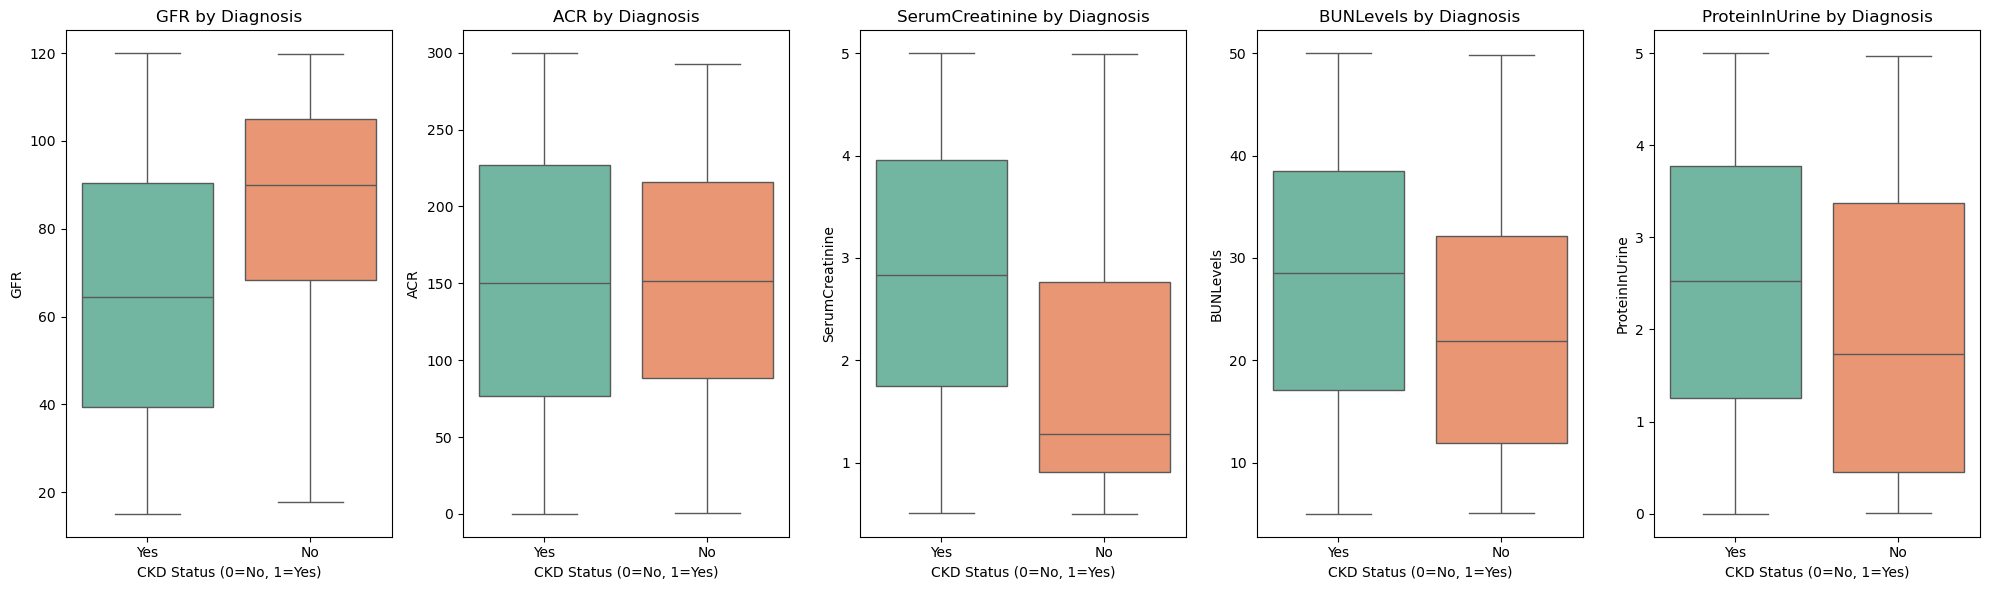

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

#  Define the biomarkers we want to visualize
biomarkers = ['GFR', 'ACR', 'SerumCreatinine', 'BUNLevels', 'ProteinInUrine']

# Create a grid: 1 row, 5 columns. 'axes' is a list of these 5 empty slots.
fig, axes = plt.subplots(1, 5, figsize=(20, 6))

# Loop through the list. 'i' is the slot index (0-4), 'marker' is the column name.
#  Enumerate gives us both the index and the value as we loop through 'biomarkers'.
for i, marker in enumerate(biomarkers):
    # Draw the boxplot in the specific slot [i]
    sns.boxplot(ax=axes[i], x='Diagnosis', y=marker, data=ckd_df, palette='Set2')
    
    # Label each plot dynamically using the biomarker name
    axes[i].set_title(f'{marker} by Diagnosis')
    axes[i].set_xlabel('CKD Status (0=No, 1=Yes)')

# Clean up the layout so titles don't overlap, then display
plt.tight_layout()
plt.show()

### How many times does a patient with abnormal biomaker have negative CKD and vice versa?

In [17]:
def plot_biomarker_diagnostic_power(df, biomarker, threshold, higher_is_abnormal=True, palette='viridis'):
    """
   Categorizes biomarker data and visualizes its diagnostic relationship with CKD.

    This function performs a threshold-based classification on a specific biomarker, 
    labeling values as 'Normal' or 'Abnormal'. it then generates a grouped bar chart 
    to show how many patients in each category were diagnosed with Chronic Kidney 
    Disease (CKD), facilitating an analysis of False Positives and False Negatives.

    Args:
        df (pd.DataFrame): The dataset containing patient records and clinical markers.
        biomarker (str): The column name of the biomarker to analyze (e.g., 'GFR', 'ACR').
        threshold (float): The clinical cutoff value used to separate categories.
        higher_is_abnormal (bool): Direction of the risk. 
            - Use True for markers where high values indicate damage (e.g., ACR, Creatinine).
            - Use False for markers where low values indicate damage (e.g., GFR).
            Defaults to True.
        palette (str): The Seaborn color palette for the plot. Defaults to 'viridis'.

    Returns:
        None: Displays a Matplotlib/Seaborn countplot with data annotations.

    Notes:
        - For GFR, the threshold is typically 90 or 60 mL/min/1.73m².
        - For ACR, a threshold of 30 mg/g is standard for detecting albuminuria.
        - This visualization is highly effective for identifying 'Grey Zones' where 
          biomarkers overlap between healthy and sick populations.

    Example:
        >>> # Analyzing GFR where values below 90 are considered abnormal
        >>> plot_biomarker_diagnostic_power(ckd_df, 'GFR', 90, higher_is_abnormal=False, palette='mako')
    """
    # 1. Categorization Logic
    if higher_is_abnormal:
        df['Temp_Status'] = df[biomarker].apply(lambda x: 'Abnormal' if x >= threshold else 'Normal')
    else:
        df['Temp_Status'] = df[biomarker].apply(lambda x: 'Abnormal' if x < threshold else 'Normal')

    # 2. Plotting (Now using the 'palette' parameter)
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=df, x='Temp_Status', hue='Diagnosis', palette=palette, order=['Abnormal', 'Normal'])

    # 3. Annotation Logic (Labeling the bars)
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', 
                        xytext=(0, 9), 
                        textcoords='offset points',
                        fontsize=11, fontweight='bold')

    # 4. Formatting
    plt.title(f'Diagnosis Breakdown by {biomarker} Status', fontsize=14)
    plt.xlabel(f'{biomarker} Category', fontsize=12)
    plt.ylabel('Patient Count', fontsize=12)
    plt.legend(title='Diagnosis (No = Healthy, Yes = CKD)') 
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    # Cleanup
    df.drop(columns=['Temp_Status'], inplace=True) 

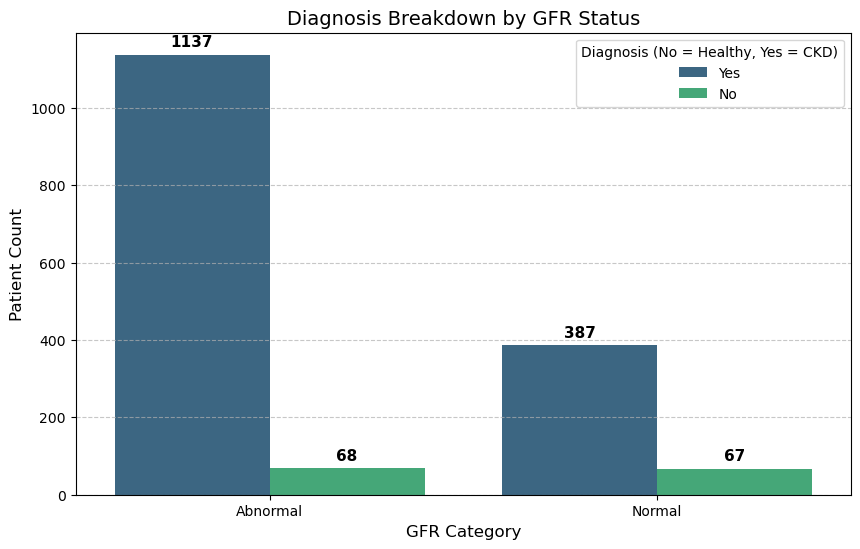

In [18]:
# Analyzing GFR where values below 90 are considered abnormal
plot_biomarker_diagnostic_power(ckd_df, 'GFR', 90, higher_is_abnormal=False, palette='viridis')

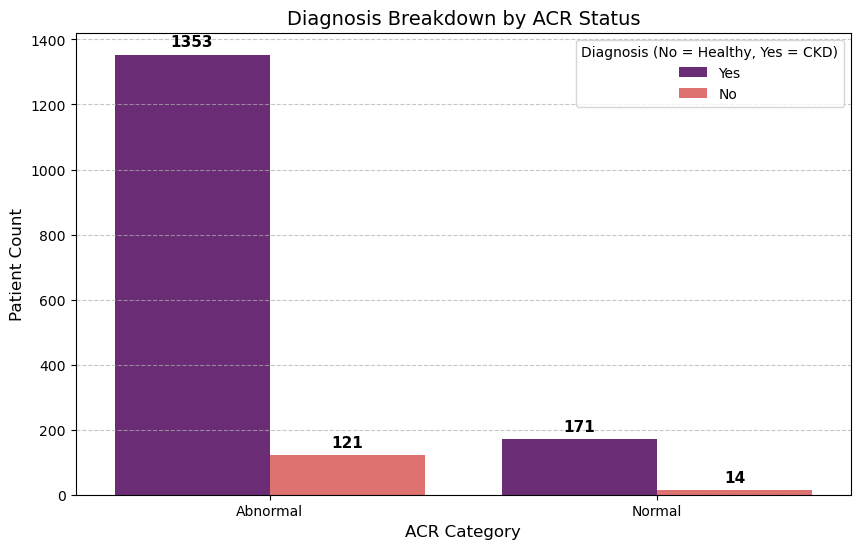

In [19]:
# Analyzing ACR where values above 30 are considered abnormal
plot_biomarker_diagnostic_power(ckd_df, 'ACR', 30, higher_is_abnormal=True, palette='magma')

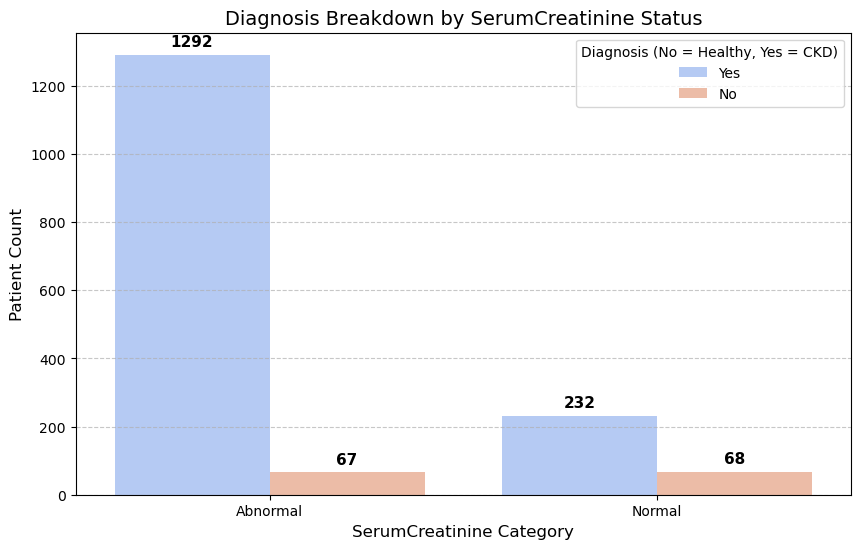

In [20]:
# Analyzing Serum Creatinine where values above 1.3 are considered abnormal
plot_biomarker_diagnostic_power(ckd_df, 'SerumCreatinine', 1.3, higher_is_abnormal=True, palette='coolwarm')

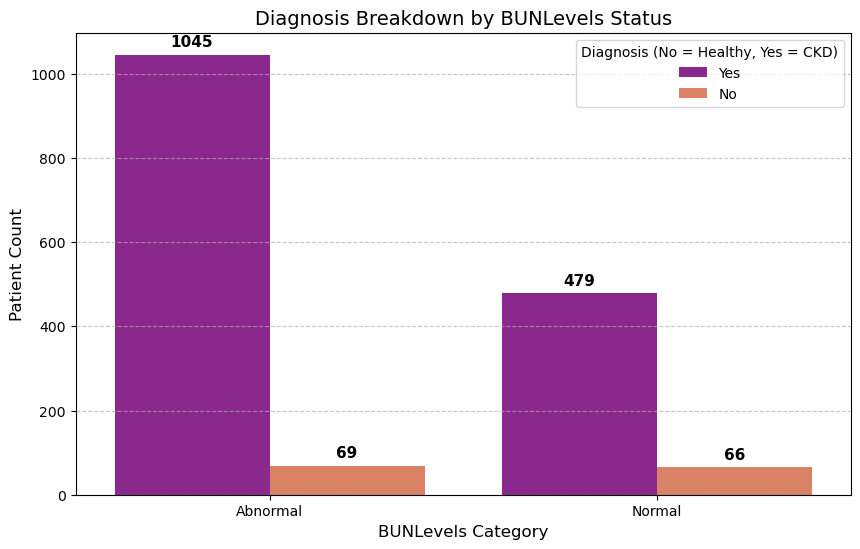

In [21]:
# Analyzing BUN Levels where values above 20 are considered abnormal
plot_biomarker_diagnostic_power(ckd_df, 'BUNLevels', 20, higher_is_abnormal=True, palette='plasma')

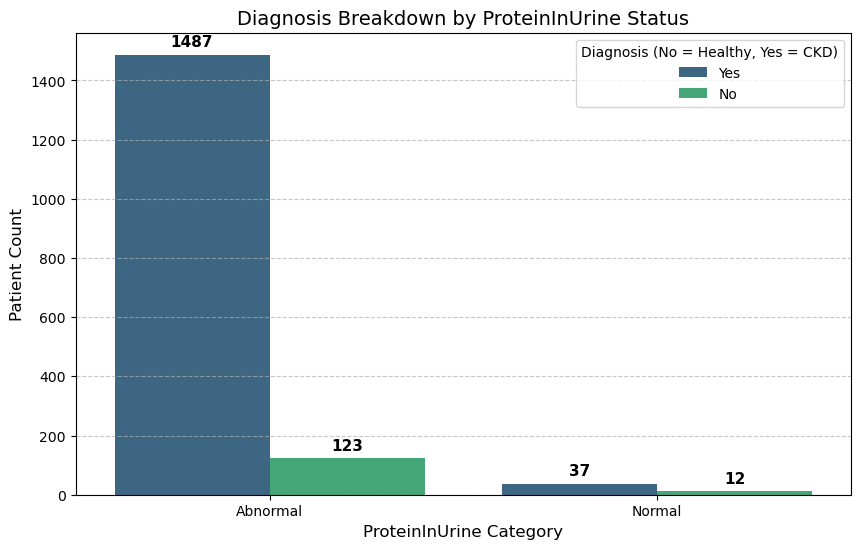

In [22]:
# Analyzing protein in urine where values above 0.15 are considered abnormal
plot_biomarker_diagnostic_power(ckd_df, 'ProteinInUrine', 0.15, higher_is_abnormal=True, palette='viridis')

C:\Users\rosea\AppData\Local\Temp\ipykernel_3112\2641383590.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Overall Accuracy (%)', y='Biomarker', ax=axes[0], palette='viridis')


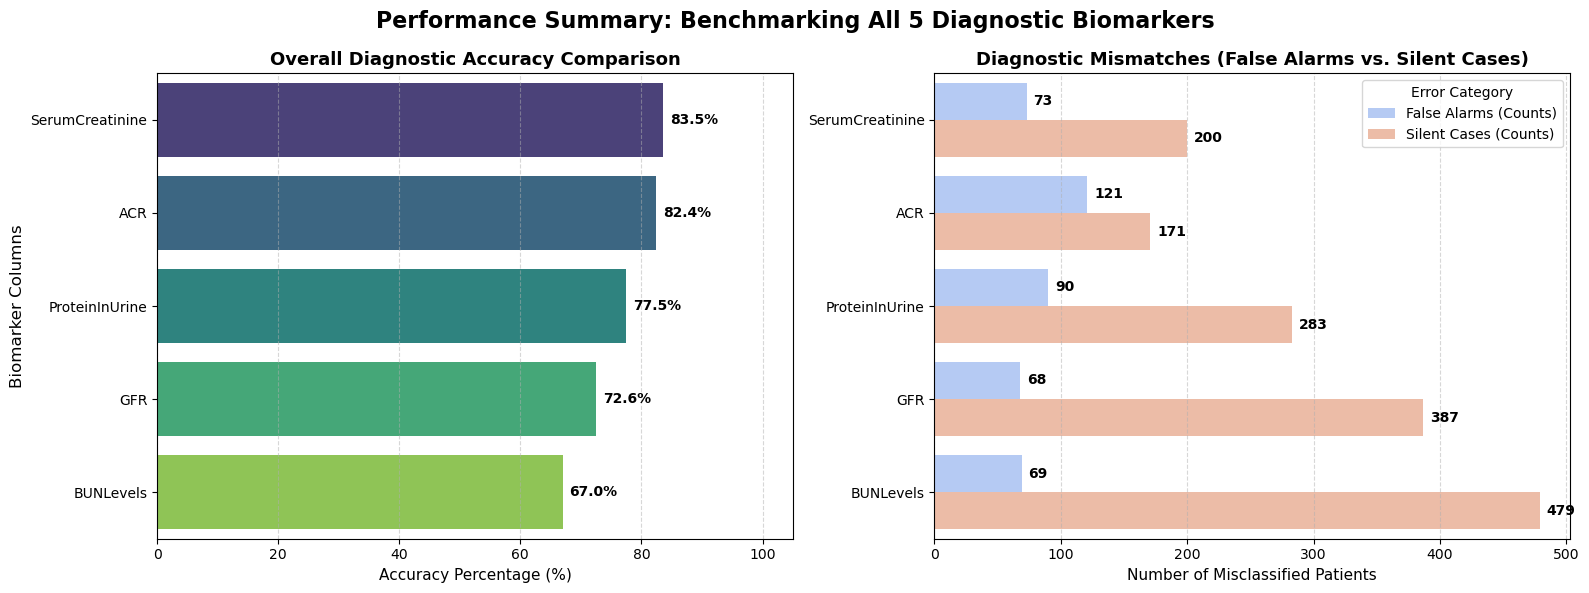

In [48]:

# 1. Define your 5 biomarkers config list
biomarkers_config = [
    {'name': 'GFR', 'threshold': 90, 'higher_is_abnormal': False},
    {'name': 'ACR', 'threshold': 30, 'higher_is_abnormal': True},
    {'name': 'SerumCreatinine', 'threshold': 1.2, 'higher_is_abnormal': True},
    {'name': 'BUNLevels', 'threshold': 20, 'higher_is_abnormal': True},
    {'name': 'ProteinInUrine', 'threshold': 1, 'higher_is_abnormal': True}
]

summary_data = []

# 2. Loop through each biomarker to calculate diagnostic accuracy
for config in biomarkers_config:
    name = config['name']
    thresh = config['threshold']
    higher_bad = config['higher_is_abnormal']
    
    # Force column to numeric type for clean comparison
    temp_series = pd.to_numeric(ckd_df[name], errors='coerce')
    
    # Classify based on the threshold rules
    if higher_bad:
        is_abnormal = temp_series >= thresh
    else:
        is_abnormal = temp_series < thresh
        
    # Calculate performance metrics relative to the true Diagnosis ('Yes'/'No')
    # True Positive: Test says Abnormal, Patient has CKD
    tp = ((is_abnormal) & (ckd_df['Diagnosis'] == 'Yes')).sum()
    # False Positive: Test says Abnormal, Patient is Healthy (False Alarm)
    fp = ((is_abnormal) & (ckd_df['Diagnosis'] == 'No')).sum()
    # True Negative: Test says Normal, Patient is Healthy
    tn = ((~is_abnormal) & (ckd_df['Diagnosis'] == 'No')).sum()
    # False Negative: Test says Normal, Patient has CKD (Silent Case)
    fn = ((~is_abnormal) & (ckd_df['Diagnosis'] == 'Yes')).sum()
    
    # Convert to rates/percentages
    total_patients = len(ckd_df)
    overall_accuracy = ((tp + tn) / total_patients) * 100
    
    summary_data.append({
        'Biomarker': name,
        'Overall Accuracy (%)': overall_accuracy,
        'False Alarms (Counts)': fp,
        'Silent Cases (Counts)': fn
    })

# Convert summary list to a DataFrame for easier plotting
metrics_df = pd.DataFrame(summary_data).sort_values(by='Overall Accuracy (%)', ascending=False)

# 3. Create the Summary Visualization (1x2 Grid)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Overall Diagnostic Accuracy Comparison
sns.barplot(data=metrics_df, x='Overall Accuracy (%)', y='Biomarker', ax=axes[0], palette='viridis')
axes[0].set_title('Overall Diagnostic Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Accuracy Percentage (%)', fontsize=11)
axes[0].set_ylabel('Biomarker Columns', fontsize=12)
axes[0].set_xlim(0, 105)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# Annotate Left Plot
for p in axes[0].patches:
    width = p.get_width()
    if width > 0:
        axes[0].annotate(f'{width:.1f}%', (width, p.get_y() + p.get_height() / 2.), 
                         ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                         fontsize=10, fontweight='bold')

# Right Plot: Diagnostic Errors (Mismatches) side-by-side
# Melting data to present FP and FN in a grouped format
melted_errors = pd.melt(metrics_df, id_vars=['Biomarker'], value_vars=['False Alarms (Counts)', 'Silent Cases (Counts)'],
                        var_name='Error Type', value_name='Patient Count')

sns.barplot(data=melted_errors, x='Patient Count', y='Biomarker', hue='Error Type', ax=axes[1], palette='coolwarm')
axes[1].set_title('Diagnostic Mismatches (False Alarms vs. Silent Cases)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Misclassified Patients', fontsize=11)
axes[1].set_ylabel('')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)
axes[1].legend(title='Error Category', loc='upper right')

# Annotate Right Plot
for p in axes[1].patches:
    width = p.get_width()
    if width > 0:
        axes[1].annotate(f'{int(width)}', (width, p.get_y() + p.get_height() / 2.), 
                         ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                         fontsize=10, fontweight='bold')

# Global adjustment
plt.suptitle('Performance Summary: Benchmarking All 5 Diagnostic Biomarkers', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### Why Biomarkers Don't Tell the Whole Story

In this analysis, I noticed that biomarkers aren't always a "perfect" match for a patient's actual health. Understanding these gaps is key to clinical diagnostics.In the dataset more patients has abnormal ACR and Protein in urine. This shows that more patients have a structural kidney impairment. I also saw some patient with anbnormal biomarkers that are healthy. What does this tell us:

#### 2. The "Hidden Damage" (Normal Test, but Sick Patient)
This is often more dangerous because the disease is "silent." It happens because:
* **Kidney Compensation:** Kidneys are overachievers. When part of the kidney is damaged, the healthy parts work twice as hard to keep blood markers looking "normal."
* **Lagging Indicators:** Some markers, like **Creatinine**, are "late bloomers." They often don't show a problem until nearly 50% of kidney function is already gone.
* **The Baseline Trap:** A patient might have a large drop in their personal kidney function, but if they started very high, their "lower" score might still fall within the "average" range.

#### 3. The Role of "Noise" in our Data
Since this is a **synthetic dataset**, these overlaps are likely intentional. In the real world, medicine isn't black and white. These "wrong" results teach us that we cannot rely on just one number.

**The Bottom Line:** 
A single biomarker is just a snapshot in time. To truly catch Chronic Kidney Disease, doctors must look at **multiple biomarkers** (like GFR and ACR together) and watch for **trends that last for months**, not just one bad day.

---

#### Biomarker Performance Summary

The comparative analysis reveals distinct trade-offs in diagnostic performance across the five assessed biomarkers, confirming that no single test is entirely flawless on its own.

* **The Pathophysiological Driver:** It is vital to ground these statistical metrics in clinical reality: **structural or functional damage to the kidney is what ultimately determines the level of each biomarker.** 

**Functional decline** represents an impairment in the kidney's dynamic operations—its ability to filter blood and clear metabolic waste. This physiological slowdown is what drives the blood-based markers, causing a plummeting **GFR** and a sharp rise in **Serum Creatinine** and **BUN Levels**.

**Structural damage**, conversely, represents a physical, anatomical breakdown of the renal tissue itself, such as glomerular tearing or interstitial scarring (fibrosis). This anatomical injury compromises the physical filtration barriers, allowing large molecules to slip through, which directly echoes in urine-based markers like **ProteinInUrine** and **ACR**.




* **Top Performance:** Biomarkers with the highest **Overall Accuracy** serve as excellent first-line screening tools because their numerical shifts tightly correlate with these objective tissue injuries, consistently mapping to the true diagnosis while maintaining a low rate of misclassifications.

* **The Clinical Trade-Off (False Alarms vs. Silent Cases):** The right-hand analysis highlights a critical clinical balance. Markers exhibiting high **False Positives (False Alarms)** tend to over-diagnose healthy individuals, which can cause unnecessary clinical anxiety and lead to costly follow-up testing. Conversely, markers with high **False Negatives (Silent Cases)** pose a much greater clinical risk; they fail to flag patients who genuinely have Chronic Kidney Disease, allowing early-stage structural micro-tears and functional decline to progress completely undetected.

#### How They Intersect
In chronic conditions like CKD, structural damage drives functional decline. For example, long-term high blood pressure physically tears the delicate structural walls of the glomerulus (structural damage). Because the barrier is damaged, proteins leak through (ACR rises), and eventually, that specific filtering unit scars over and dies. As thousands of these units die off, the global filtration speed of the kidney drops (functional damage, causing GFR to plummet).

Understanding this sequence is precisely why clinical screening requires both blood tests (for function) and urine tests (for structure) to get a true picture of kidney health.

**Final Takeaway:** Because certain biomarkers excel at minimizing false alarms while others are better at eliminating silent cases, using these tests in combination—rather than relying on any single marker in isolation—is the most effective strategy to bridge the gap between abstract data thresholds and the underlying structural and functional reality of renal disease.



### Can a patient have CKD when all 5 biomarkers are normal? 

In [24]:

def analyze_biomarker_filters(df, biomarkers_config, target_col='Diagnosis'):
    """
    Performs an iterative step-down analysis to track patient attrition across biomarkers.

    This function starts with a specific population (e.g., CKD positive patients) and 
    sequentially applies biomarker filters. It tracks how many patients are 'caught' 
    (identified as abnormal) by each specific marker and how many continue to 
    test 'normal' as the criteria become more cumulative.

    Args:
        df (pd.DataFrame): The clinical dataset containing biomarkers and target labels.
        biomarkers_config (list of dict): A sequence of dictionaries defining the filters.
            Each dictionary must include:
            - 'name' (str): The column name in the DataFrame.
            - 'threshold' (float): The clinical cutoff value.
            - 'higher_is_abnormal' (bool): 
                - True: Values >= threshold are Abnormal (e.g., Protein, ACR).
                - False: Values < threshold are Abnormal (e.g., GFR).
        target_col (str): The column used for the initial population subset. 
            Defaults to 'Diagnosis'.

    Returns:
        pd.DataFrame: A step-by-step summary table including:
            - Step: The name of the filter applied.
            - Patients_Remaining: Count of patients still testing 'Normal' after the filter.
            - Patients_Caught: Count of patients removed because they tested 'Abnormal'.

    Notes:
        - Logic Correction: This function treats the threshold as the start of the 
          Abnormal range. For 'higher_is_abnormal', a value exactly equal to the 
          threshold is categorized as Abnormal and removed from the 'Normal' pool.
        - Data Cleaning: The function automatically converts biomarker columns to 
          numeric to prevent comparison errors caused by string-type data.

    Example:
        >>> config = [{'name': 'ProteinInUrine', 'threshold': 1, 'higher_is_abnormal': True}]
        >>> report = analyze_biomarker_stepdown(ckd_df, config)
        >>> print(report)
    """
    
    # 1. Initialize the subset with only the positive cases (e.g., Diagnosis == 1)
    # We use .copy() to avoid SettingWithCopy warnings during numeric conversion
    current_pool = df[df[target_col] == 'Yes'].copy()
    initial_total = len(current_pool)
    
    # 2. Setup the results tracker
    history = [{
        'Step': 'Initial Positive Population',
        'Patients_Remaining': initial_total,
        'Patients_Caught': 0
    }]

    # 3. Iterate through markers and filter the pool
    for config in biomarkers_config:
        name = config['name']
        thresh = config['threshold']
        higher_bad = config['higher_is_abnormal']
        
        # Safety: Ensure the column is numeric so comparisons ( < , > ) work correctly
        current_pool[name] = pd.to_numeric(current_pool[name], errors='coerce')
        
        if higher_bad:
            # ABNORMAL is >= threshold. NORMAL is strictly < threshold.
            # This ensures that if Protein is 1 and threshold is 1, they are caught.
            is_normal = current_pool[name] < thresh
        else:
            # ABNORMAL is < threshold. NORMAL is >= threshold.
            is_normal = current_pool[name] >= thresh
            
        # Calculate counts
        remaining_count = is_normal.sum()
        caught_count = len(current_pool) - remaining_count
        
        # Update history
        history.append({
            'Step': f'Filter: {name}',
            'Patients_Remaining': int(remaining_count),
            'Patients_Caught': int(caught_count)
        })
        
        # Step Down: The remaining 'Normal' patients become the pool for the next filter
        current_pool = current_pool[is_normal]
        
        # Stop if no patients are left to filter
        if len(current_pool) == 0:
            break

    return pd.DataFrame(history)

In [25]:
# Setup your biomarkers
my_config = [
    {'name': 'GFR', 'threshold': 90, 'higher_is_abnormal': False},
    {'name': 'ACR', 'threshold': 30, 'higher_is_abnormal': True},
    {'name': 'SerumCreatinine', 'threshold': 1.2, 'higher_is_abnormal': True},
    {'name': 'BUNLevels', 'threshold': 20, 'higher_is_abnormal': True},
    {'name': 'ProteinInUrine', 'threshold': 0.15, 'higher_is_abnormal': True}
]

# Run the analysis
summary_table = analyze_biomarker_filters(ckd_df, my_config)

# View the summary table of the step-down analysis
display(summary_table)

,Step,Patients_Remaining,Patients_Caught
0,Initial Positive Population,1524,0
1,Filter: GFR,387,1137
2,Filter: ACR,40,347
3,Filter: SerumCreatinine,3,37
4,Filter: BUNLevels,1,2
5,Filter: ProteinInUrine,0,1


In [26]:
# 1. Define your clinical thresholds for 'Normal' levels
# Adjust these numbers based on your specific medical guidelines
conditions = [
    (ckd_df['Diagnosis'] == 'Yes'),               # Patient MUST have CKD
    (ckd_df['GFR'] >= 90),                        # GFR is in the normal range
    (ckd_df['ProteinInUrine'] < 0.15),            # Protein is in normal
    (ckd_df['ACR'] < 30),                         # ACR is in the normal range
    (ckd_df['SerumCreatinine'] < 1.2),            # Creatinine is in the normal range
    (ckd_df['BUNLevels'] < 20)                    # BUN is in the normal range
]

# 2. Combine all conditions using the 'AND' operator (&)
# This finds patients who meet every single criteria above
is_silent_ckd = pd.concat(conditions, axis=1).all(axis=1)

# 3. Create the final dataframe of these specific patients
silent_patients = ckd_df[is_silent_ckd].copy()

# 4. Display the results
print(f"Total 'Silent' CKD Patients found: {len(silent_patients)}")
display(silent_patients.head())

Total 'Silent' CKD Patients found: 0


,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,MuscleCramps,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis


## The Absence of "Silent CKD"

After performing a full **Cascade Analysis** and cross-referencing all five biomarkers (GFR, ACR, Protein, Creatinine, and BUN), I found that **zero patients** in this dataset were diagnosed with CKD while maintaining "Normal" levels across every single test.

While this result suggests that our testing suite is highly effective at "catching" the disease, there are two important takeaways to keep in mind:

*   **The "At Least One" Rule:** In this specific dataset, every patient with CKD triggered at least one "Abnormal" alarm. Even if their GFR looked healthy, their Protein or ACR levels were high enough to signal a problem.
*   **Synthetic vs. Real World:** It is vital to remember that this is **synthetic data**. While it is excellent for modeling and practice, it often has cleaner boundaries than real-life biology. In a clinical setting, "Silent CKD" (Stage 1) can occasionally exist where blood and urine markers appear normal, but physical damage is visible only via imaging (like an ultrasound).



## Checking For Correlation Between columns

In [27]:
# Correlation between numerical columns
numerical_cols = ckd_df.select_dtypes(include=[np.number]).columns  
correlation_matrix = ckd_df[numerical_cols].corr()
correlation_matrix

,PatientID,Age,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,SystolicBP,DiastolicBP,FastingBloodSugar,...,CholesterolTriglycerides,NSAIDsUse,FatigueLevels,NauseaVomiting,MuscleCramps,Itching,QualityOfLifeScore,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy
PatientID,1.000000,0.001166,-0.036264,0.029087,-0.003768,0.017805,-0.027967,-0.056561,-0.003990,0.031931,...,0.033592,0.013110,-0.010984,-0.019741,0.003806,-0.042814,-0.011147,-0.018654,0.001955,0.004524
Age,0.001166,1.000000,-0.033202,-0.006030,0.003485,0.004062,-0.005151,0.050918,0.007282,-0.006815,...,-0.021061,0.019042,0.002977,-0.029556,0.001318,0.005683,-0.022676,-0.015165,0.043168,0.010920
BMI,-0.036264,-0.033202,1.000000,-0.067239,0.003528,0.014539,0.011668,-0.017086,0.020390,0.022776,...,0.040651,-0.003156,0.009345,0.023334,-0.030355,0.023998,-0.046046,0.002934,0.020329,-0.015661
AlcoholConsumption,0.029087,-0.006030,-0.067239,1.000000,0.056835,-0.026931,0.025684,0.025550,-0.030295,-0.006975,...,0.008030,-0.017272,-0.041375,0.021581,-0.008730,0.018152,0.000959,0.022099,0.011002,-0.012806
PhysicalActivity,-0.003768,0.003485,0.003528,0.056835,1.000000,0.028995,0.027778,-0.002123,-0.003686,0.008377,...,-0.009947,0.023746,0.014802,-0.024660,0.035289,-0.011907,0.006563,-0.017973,0.059385,0.007185
DietQuality,0.017805,0.004062,0.014539,-0.026931,0.028995,1.000000,-0.001167,0.018914,-0.032950,0.010676,...,-0.000174,0.010630,-0.004170,-0.013537,0.040590,-0.041057,-0.008491,0.035851,-0.045941,-0.014740
SleepQuality,-0.027967,-0.005151,0.011668,0.025684,0.027778,-0.001167,1.000000,-0.024671,-0.014668,-0.050340,...,-0.023590,0.002088,0.032695,0.053687,0.004537,-0.005265,0.007986,0.003318,-0.007660,0.035393
SystolicBP,-0.056561,0.050918,-0.017086,0.025550,-0.002123,0.018914,-0.024671,1.000000,-0.022278,-0.046875,...,-0.001697,-0.001205,-0.001497,0.002677,0.011400,-0.015591,0.029407,-0.040960,0.003990,-0.015852
DiastolicBP,-0.003990,0.007282,0.020390,-0.030295,-0.003686,-0.032950,-0.014668,-0.022278,1.000000,-0.006918,...,0.013657,-0.003046,-0.022700,0.016192,-0.000438,0.005802,-0.026415,-0.009208,0.025991,-0.023225
FastingBloodSugar,0.031931,-0.006815,0.022776,-0.006975,0.008377,0.010676,-0.050340,-0.046875,-0.006918,1.000000,...,0.027812,-0.015878,0.017620,0.016942,-0.004482,-0.014312,0.049155,-0.018368,-0.021860,0.015248


###  What is the relationship between Serum Creatinine level and GFR?

In [28]:
# Correllation between Serum Creatinine and GFR
corr_creatinine_gfr = ckd_df['SerumCreatinine'].corr(ckd_df['GFR'])
print(f"Correlation between Serum Creatinine and GFR: {corr_creatinine_gfr:.5f}")

Correlation between Serum Creatinine and GFR: -0.00343


C:\Users\rosea\AppData\Local\Temp\ipykernel_3112\2901800559.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=ckd_df, x='SerumCreatinine', y='GFR', palette='Set1')


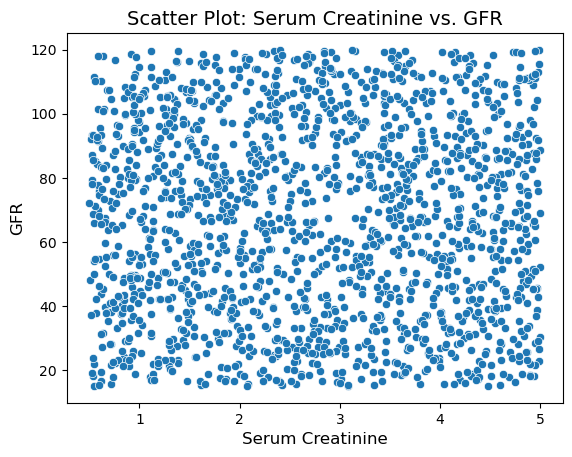

In [29]:
# Scatter plot between serum creatinine and GFR
sns.scatterplot(data=ckd_df, x='SerumCreatinine', y='GFR', palette='Set1')
plt.title('Scatter Plot: Serum Creatinine vs. GFR', fontsize=14)
plt.xlabel('Serum Creatinine', fontsize=12)
plt.ylabel('GFR', fontsize=12)
plt.show()

#### The above does not make sense clinically. Although it was not stated whether the GFR was measured or estimated in the dataset, it was still suppose to have a strong correlation with serum creatinine. This is one of the beautiful limitation of a synthetic dataset.

###  What is the relationship between age and GFR?

In [30]:
# Correlation between Age and GFR
corr_age_gfr = ckd_df['Age'].corr(ckd_df['GFR'])
print(f"Correlation between Age and GFR: {corr_age_gfr:.5f}")

Correlation between Age and GFR: 0.04583


C:\Users\rosea\AppData\Local\Temp\ipykernel_3112\2688795703.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=ckd_df, x='Age', y='GFR', palette='Set2')


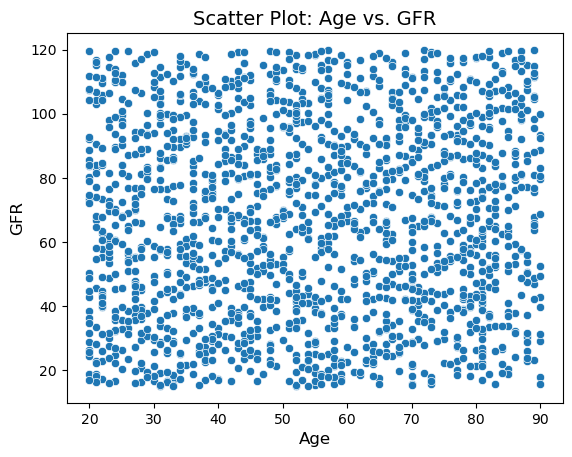

In [31]:
# Scatter plot between Age and GFR
sns.scatterplot(data=ckd_df, x='Age', y='GFR', palette='Set2')
plt.title('Scatter Plot: Age vs. GFR', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('GFR', fontsize=12)
plt.show()

### Is there any correlation between other clinical measurements and Biomakers

In [32]:
# Selecting other relevant Clinical Measurements and biomarkers columns for further analysis
ckd_clinical_biomarkers = ckd_df[['SystolicBP', 'DiastolicBP',
       'FastingBloodSugar', 'HbA1c', 'SerumCreatinine', 'BUNLevels', 'GFR',
       'ProteinInUrine', 'ACR', 'SerumElectrolytesSodium',
       'SerumElectrolytesPotassium', 'SerumElectrolytesCalcium',
       'SerumElectrolytesPhosphorus', 'HemoglobinLevels', 'CholesterolTotal',
       'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides']]

# Correlation of other clinical measurements and Biomakers
corr_clinical_biomarkers = ckd_clinical_biomarkers.corr()
corr_clinical_biomarkers = corr_clinical_biomarkers[['GFR','BUNLevels','ProteinInUrine']].sort_values(by=['GFR', 'BUNLevels', 'ProteinInUrine'], ascending=False)
print("Correlation of Clinical Measurements with Biomarkers:")
print(corr_clinical_biomarkers)

Correlation of Clinical Measurements with Biomarkers:
                                  GFR  BUNLevels  ProteinInUrine
GFR                          1.000000  -0.036221       -0.009442
SerumElectrolytesPotassium   0.020225   0.001759       -0.017865
SerumElectrolytesPhosphorus  0.018832  -0.009338       -0.044162
SerumElectrolytesSodium      0.011776  -0.013878       -0.024127
SystolicBP                   0.009462   0.021084       -0.012435
FastingBloodSugar            0.008208  -0.013031       -0.036826
CholesterolHDL               0.002722   0.012696        0.041872
CholesterolLDL               0.002333  -0.011274        0.026595
DiastolicBP                 -0.001276   0.006522       -0.002373
SerumCreatinine             -0.003434   0.022555       -0.037101
ACR                         -0.008342   0.011626       -0.014503
ProteinInUrine              -0.009442  -0.000365        1.000000
CholesterolTotal            -0.014407   0.015287        0.044105
HemoglobinLevels            -0.01916

##### Synthetic data is beautifully funny. There is no correlation between any feature.

## Effect of Risk Factors on CKD

#### Let's go Deeper to see the story our dataset tells about CKD risk factors

In [33]:

def analyze_risk_factor_percentages(df, risk_column, target_col='Diagnosis', palette='coolwarm'):
    """
    Calculates and visualizes conditional percentages between a risk factor and a diagnosis.

    This function breaks down a categorical risk factor column (e.g., 'Yes'/'No') 
    by the target diagnosis status. It calculates the percentage distribution of the 
    risk factor within the sick population and within the healthy population separately, 
    then visualizes the result as a 100% stacked bar chart.

    Args:
        df (pd.DataFrame): The clinical dataset.
        risk_column (str): The column name of the risk factor to analyze (must be categorical, e.g., 'Yes'/'No').
        target_col (str): The column indicating disease status (Yes = Positive, No = Negative).
            Defaults to 'Diagnosis'.
        palette (str): The Seaborn color palette for the plot. Defaults to 'coolwarm'.

    Returns:
        pd.DataFrame: A cross-tabulation table showing the exact calculated percentages.

    Notes:
        - This analysis helps identify if a risk factor is disproportionately present 
          in sick patients compared to healthy ones (indicating a potential correlation).
        - The visual output uses a 100% stacked bar chart to make percentage comparisons 
          intuitive, regardless of differences in the total sizes of the groups.

    Example:
        >>> # Assuming 'HistoryOfHypertension' has values 'Yes' and 'No'
        >>> pct_table = analyze_risk_factor_percentages(ckd_df, 'HistoryOfHypertension')
        >>> display(pct_table)
    """
    # 1. Create a cross-tabulation table (counts)
    crosstab = pd.crosstab(df[target_col], df[risk_column])
    
    # 2. Convert counts to percentages along the rows (normalize by Diagnosis group)
    # This divides each row by the sum of that row and multiplies by 100
    pct_tab = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    
    # Rename the index rows for clearer console reading
    pct_tab.index = pct_tab.index.map({'Yes': 'Diagnosis: YES (Sick)', 'No': 'Diagnosis: NO (Healthy)'})
    
    print(f"--- Percentage Breakdown for Risk Factor: {risk_column} ---")
    print("-" * 65)
    
    # 3. Plotting a 100% Stacked Bar Chart
    # Kind='barh' makes it a horizontal stacked bar, which is highly readable for percentages
    ax = pct_tab.plot(kind='barh', stacked=True, figsize=(10, 5), colormap=plt.cm.get_cmap(palette))
    
    # 4. Add the percentage labels directly inside the colored bars
    for p in ax.patches:
        width = p.get_width()
        if width > 0:  # Only label if the percentage bar is wider than 0%
            # Find the center of the current colored segment
            x_pos = p.get_x() + width / 2
            y_pos = p.get_y() + p.get_height() / 2
            ax.annotate(f'{width:.1f}%', 
                        (x_pos, y_pos), 
                        ha='center', va='center', 
                        fontsize=11, fontweight='bold', color='white')

    # Formatting the visual canvas
    plt.title(f'Distribution of {risk_column} within Diagnosis Groups', fontsize=14)
    plt.xlabel('Percentage (%)', fontsize=12)
    plt.ylabel('')
    plt.xlim(0, 100)
    plt.legend(title=risk_column, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    return pct_tab

In [34]:
ckd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PatientID                      1659 non-null   int64  
 1   Age                            1659 non-null   int64  
 2   Gender                         1659 non-null   object 
 3   Ethnicity                      1659 non-null   object 
 4   SocioeconomicStatus            1659 non-null   object 
 5   EducationLevel                 1659 non-null   object 
 6   BMI                            1659 non-null   float64
 7   Smoking                        1659 non-null   object 
 8   AlcoholConsumption             1659 non-null   float64
 9   PhysicalActivity               1659 non-null   float64
 10  DietQuality                    1659 non-null   float64
 11  SleepQuality                   1659 non-null   float64
 12  FamilyHistoryKidneyDisease     1659 non-null   o

--- Percentage Breakdown for Risk Factor: Smoking ---
-----------------------------------------------------------------


C:\Users\rosea\AppData\Local\Temp\ipykernel_3112\480877227.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax = pct_tab.plot(kind='barh', stacked=True, figsize=(10, 5), colormap=plt.cm.get_cmap(palette))


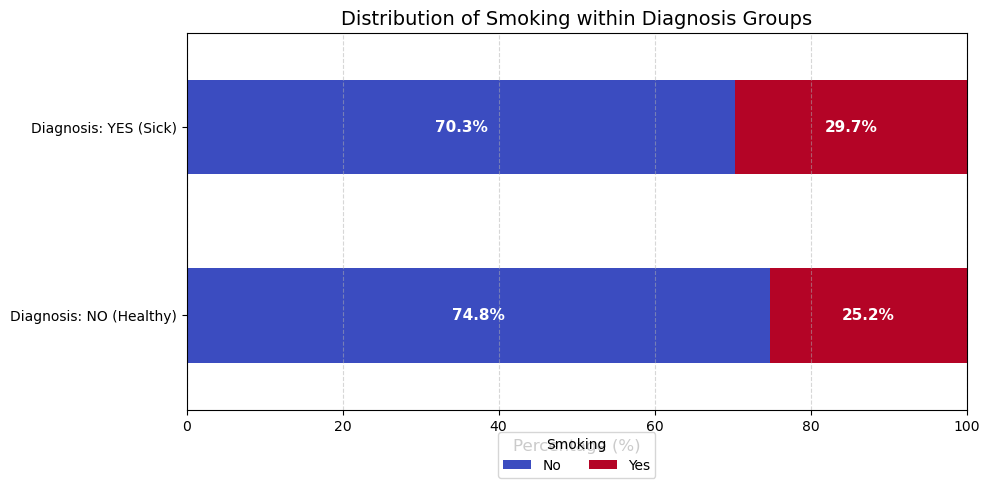

Smoking,No,Yes
Diagnosis,,
Diagnosis: NO (Healthy),74.814815,25.185185
Diagnosis: YES (Sick),70.341207,29.658793


In [35]:
analyze_risk_factor_percentages(ckd_df,'Smoking')

--- Percentage Breakdown for Risk Factor: FamilyHistoryKidneyDisease ---
-----------------------------------------------------------------


C:\Users\rosea\AppData\Local\Temp\ipykernel_3112\480877227.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax = pct_tab.plot(kind='barh', stacked=True, figsize=(10, 5), colormap=plt.cm.get_cmap(palette))


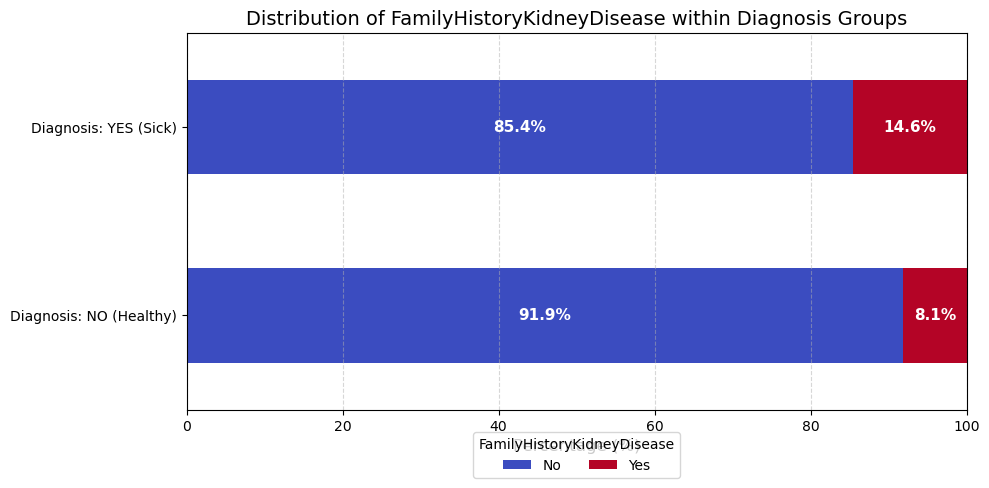

FamilyHistoryKidneyDisease,No,Yes
Diagnosis,,
Diagnosis: NO (Healthy),91.851852,8.148148
Diagnosis: YES (Sick),85.367454,14.632546


In [36]:
analyze_risk_factor_percentages(ckd_df,'FamilyHistoryKidneyDisease')

--- Percentage Breakdown for Risk Factor: FamilyHistoryHypertension ---
-----------------------------------------------------------------


C:\Users\rosea\AppData\Local\Temp\ipykernel_3112\480877227.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax = pct_tab.plot(kind='barh', stacked=True, figsize=(10, 5), colormap=plt.cm.get_cmap(palette))


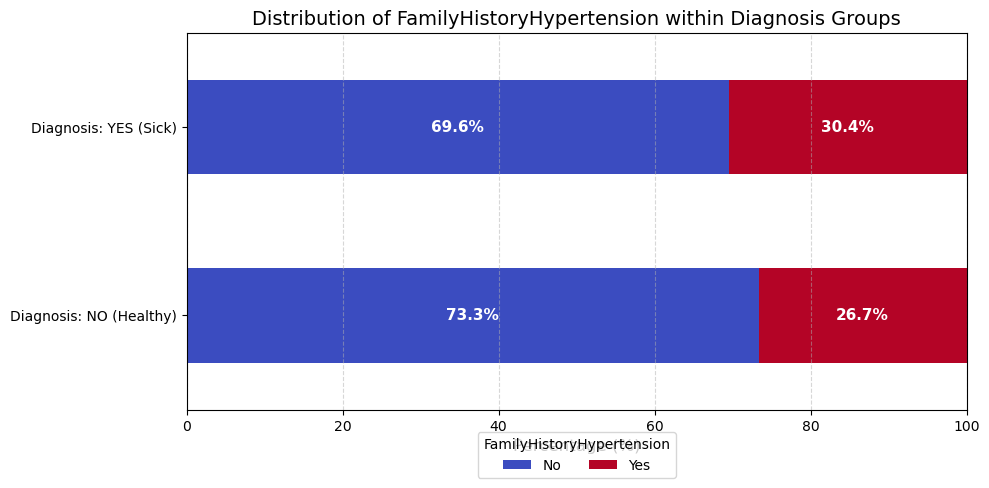

FamilyHistoryHypertension,No,Yes
Diagnosis,,
Diagnosis: NO (Healthy),73.333333,26.666667
Diagnosis: YES (Sick),69.553806,30.446194


In [37]:
analyze_risk_factor_percentages(ckd_df,'FamilyHistoryHypertension')

--- Percentage Breakdown for Risk Factor: FamilyHistoryDiabetes ---
-----------------------------------------------------------------


C:\Users\rosea\AppData\Local\Temp\ipykernel_3112\480877227.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax = pct_tab.plot(kind='barh', stacked=True, figsize=(10, 5), colormap=plt.cm.get_cmap(palette))


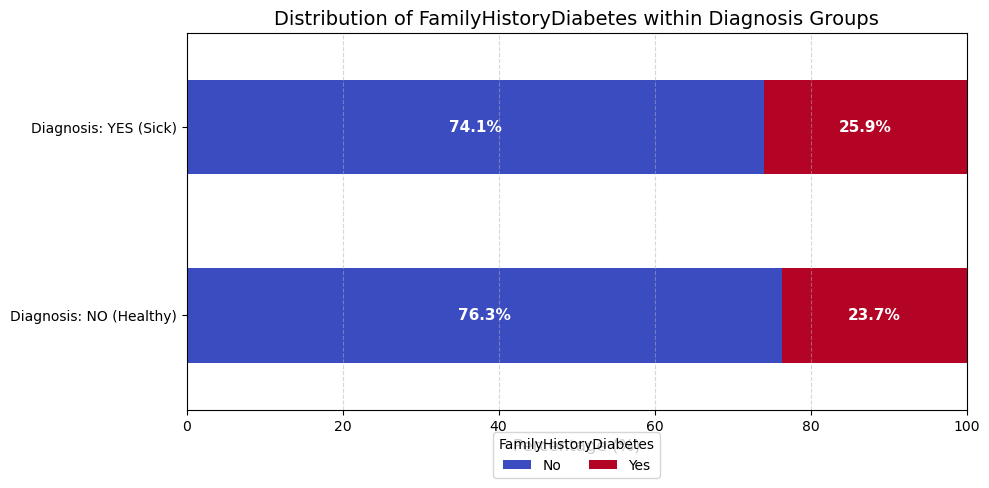

FamilyHistoryDiabetes,No,Yes
Diagnosis,,
Diagnosis: NO (Healthy),76.296296,23.703704
Diagnosis: YES (Sick),74.081365,25.918635


In [38]:
analyze_risk_factor_percentages(ckd_df,'FamilyHistoryDiabetes')

--- Percentage Breakdown for Risk Factor: PreviousAcuteKidneyInjury ---
-----------------------------------------------------------------


C:\Users\rosea\AppData\Local\Temp\ipykernel_3112\480877227.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax = pct_tab.plot(kind='barh', stacked=True, figsize=(10, 5), colormap=plt.cm.get_cmap(palette))


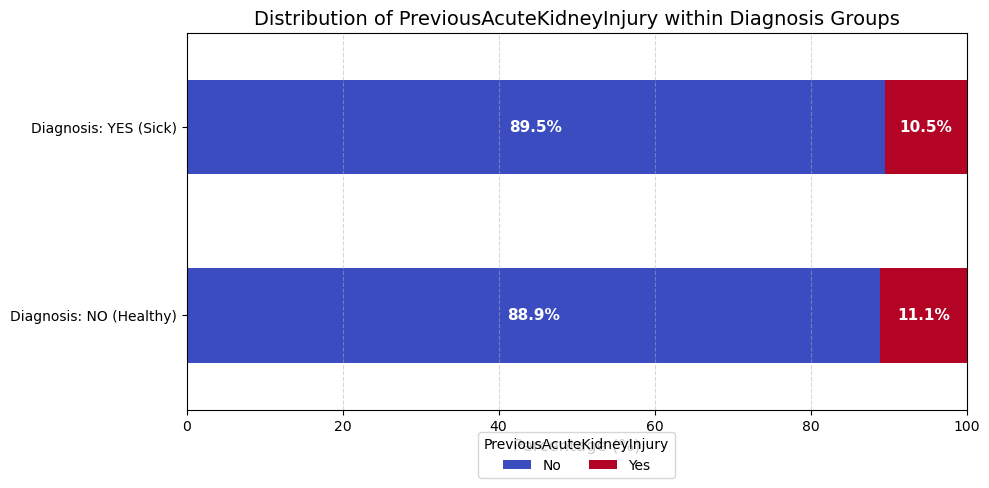

PreviousAcuteKidneyInjury,No,Yes
Diagnosis,,
Diagnosis: NO (Healthy),88.888889,11.111111
Diagnosis: YES (Sick),89.501312,10.498688


In [39]:
analyze_risk_factor_percentages(ckd_df,'PreviousAcuteKidneyInjury')

--- Percentage Breakdown for Risk Factor: UrinaryTractInfections ---
-----------------------------------------------------------------


C:\Users\rosea\AppData\Local\Temp\ipykernel_3112\480877227.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax = pct_tab.plot(kind='barh', stacked=True, figsize=(10, 5), colormap=plt.cm.get_cmap(palette))


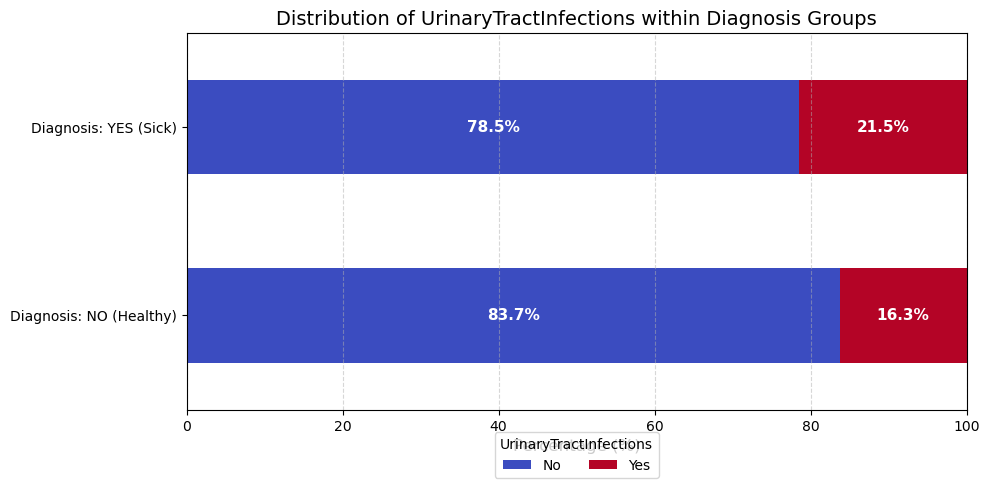

UrinaryTractInfections,No,Yes
Diagnosis,,
Diagnosis: NO (Healthy),83.703704,16.296296
Diagnosis: YES (Sick),78.543307,21.456693


In [40]:
analyze_risk_factor_percentages(ckd_df,'UrinaryTractInfections')

--- Percentage Breakdown for Risk Factor: WaterQuality ---
-----------------------------------------------------------------


C:\Users\rosea\AppData\Local\Temp\ipykernel_3112\480877227.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax = pct_tab.plot(kind='barh', stacked=True, figsize=(10, 5), colormap=plt.cm.get_cmap(palette))


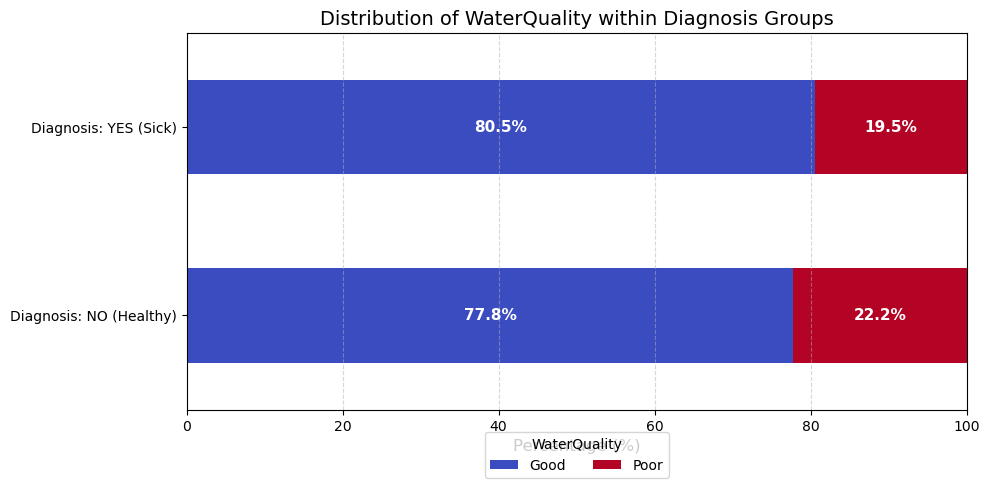

WaterQuality,Good,Poor
Diagnosis,,
Diagnosis: NO (Healthy),77.777778,22.222222
Diagnosis: YES (Sick),80.511811,19.488189


In [41]:
analyze_risk_factor_percentages(ckd_df,'WaterQuality')

--- Percentage Breakdown for Risk Factor: HeavyMetalsExposure ---
-----------------------------------------------------------------


C:\Users\rosea\AppData\Local\Temp\ipykernel_3112\480877227.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax = pct_tab.plot(kind='barh', stacked=True, figsize=(10, 5), colormap=plt.cm.get_cmap(palette))


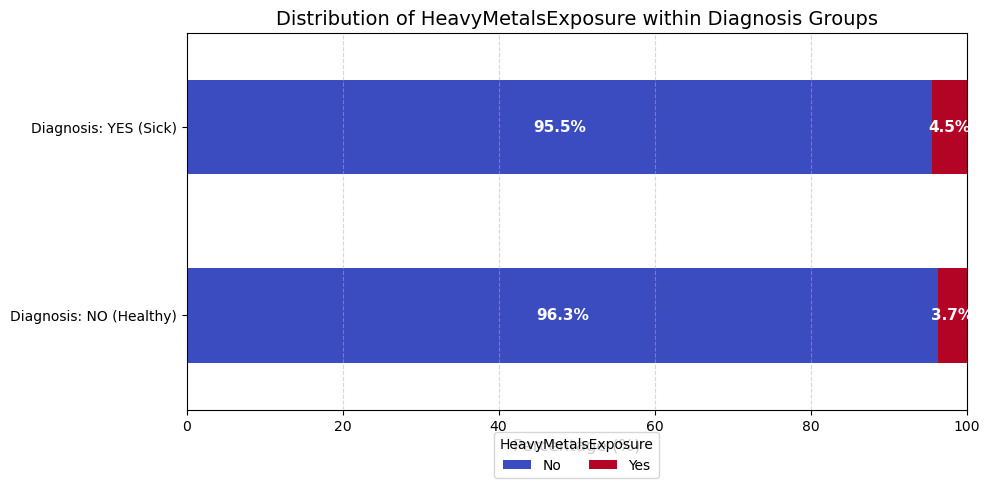

HeavyMetalsExposure,No,Yes
Diagnosis,,
Diagnosis: NO (Healthy),96.296296,3.703704
Diagnosis: YES (Sick),95.538058,4.461942


In [42]:
analyze_risk_factor_percentages(ckd_df,'HeavyMetalsExposure')

--- Percentage Breakdown for Risk Factor: OccupationalExposureChemicals ---
-----------------------------------------------------------------


C:\Users\rosea\AppData\Local\Temp\ipykernel_3112\480877227.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax = pct_tab.plot(kind='barh', stacked=True, figsize=(10, 5), colormap=plt.cm.get_cmap(palette))


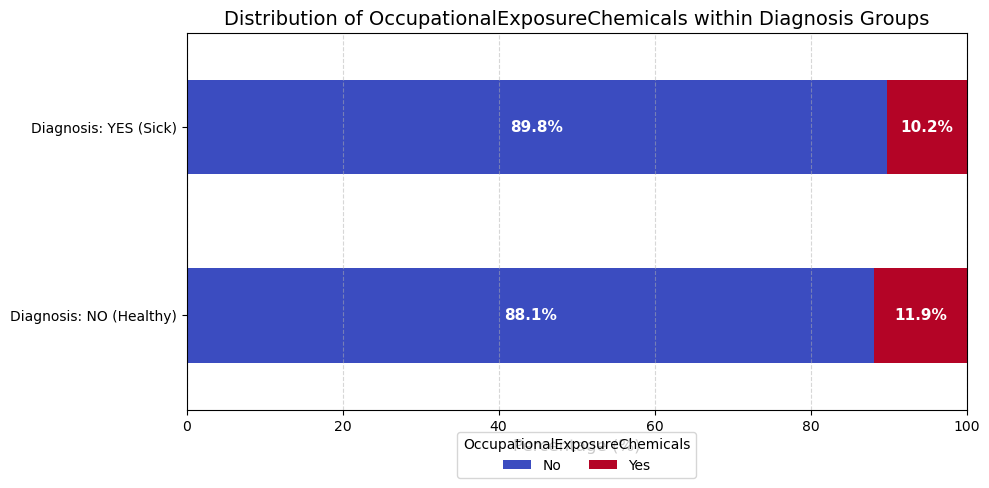

OccupationalExposureChemicals,No,Yes
Diagnosis,,
Diagnosis: NO (Healthy),88.148148,11.851852
Diagnosis: YES (Sick),89.829396,10.170604


In [43]:
analyze_risk_factor_percentages(ckd_df,'OccupationalExposureChemicals')

In [44]:
# Convert 'Poor' to 'Yes' (Risk Present) and 'Good' to 'No' (Risk Absent)
ckd_df['WaterQuality'] = ckd_df['WaterQuality'].map({'Poor': 'Yes', 'Good': 'No'})

C:\Users\rosea\AppData\Local\Temp\ipykernel_3112\1425321747.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='Sick_Prevalence', y='Risk_Factor', ax=axes[0], palette='rocket')
C:\Users\rosea\AppData\Local\Temp\ipykernel_3112\1425321747.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='Healthy_Prevalence', y='Risk_Factor', ax=axes[1], palette='crest')


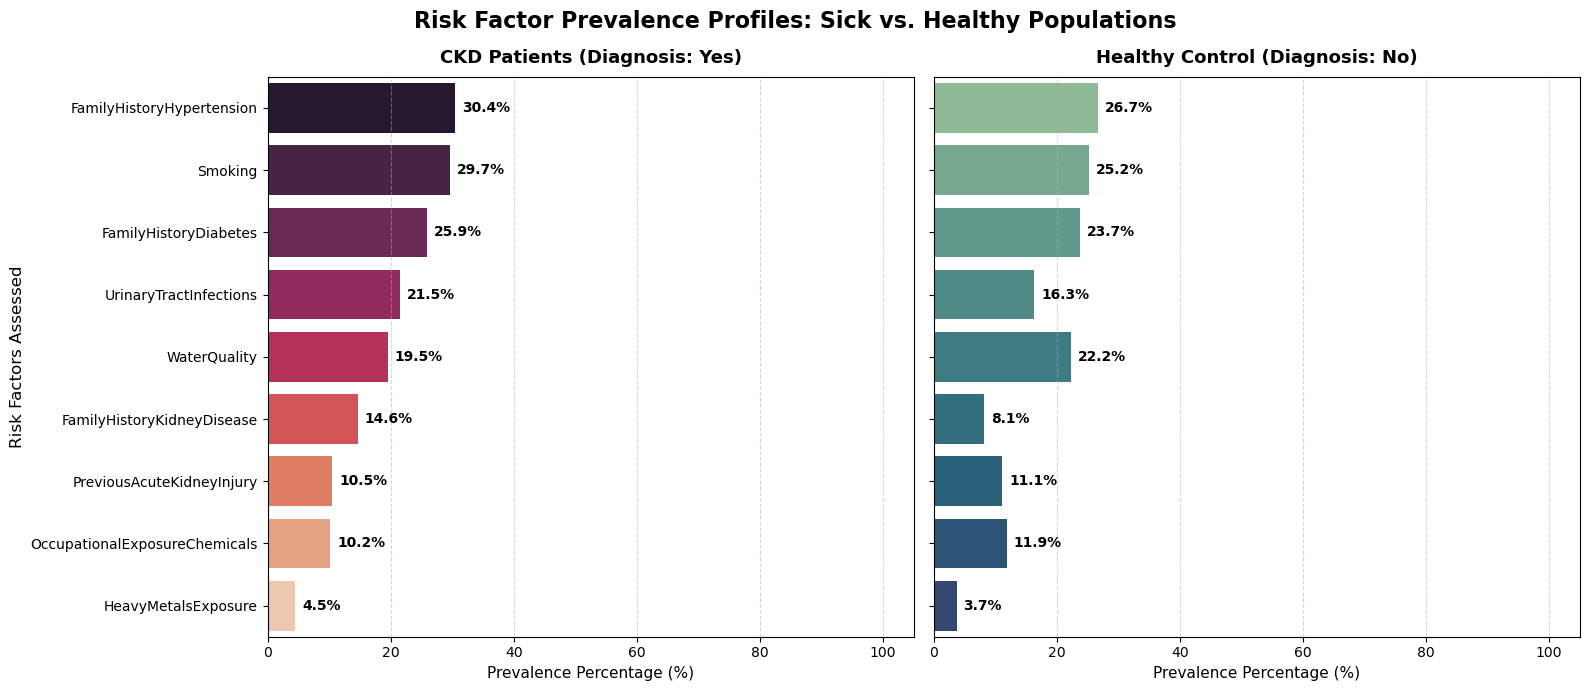

In [45]:

# 1. Define your 9 risk factor columns
nine_risk_factors = [
    'Smoking', 'FamilyHistoryKidneyDisease', 'FamilyHistoryHypertension', 
    'FamilyHistoryDiabetes', 'WaterQuality', 'PreviousAcuteKidneyInjury', 
    'UrinaryTractInfections', 'HeavyMetalsExposure', 'OccupationalExposureChemicals'
]

# 2. Split the dataset into sick and healthy populations
sick_pop = ckd_df[ckd_df['Diagnosis'] == 'Yes']
healthy_pop = ckd_df[ckd_df['Diagnosis'] == 'No']

total_sick = len(sick_pop)
total_healthy = len(healthy_pop)

# 3. Calculate 'Yes' percentages for both groups
prevalence_data = []
for column in nine_risk_factors:
    sick_pct = ((sick_pop[column] == 'Yes').sum() / total_sick) * 100 if total_sick > 0 else 0
    healthy_pct = ((healthy_pop[column] == 'Yes').sum() / total_healthy) * 100 if total_healthy > 0 else 0
    
    prevalence_data.append({
        'Risk_Factor': column,
        'Sick_Prevalence': sick_pct,
        'Healthy_Prevalence': healthy_pct
    })

# Convert to DataFrame and sort by prevalence in the sick population
summary_df = pd.DataFrame(prevalence_data).sort_values(by='Sick_Prevalence', ascending=False)

# 4. Set up a 1x2 Grid of subplots sharing the same Y-axis for clean comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# --- Left Plot: Sick Population ---
sns.barplot(data=summary_df, x='Sick_Prevalence', y='Risk_Factor', ax=axes[0], palette='rocket')
axes[0].set_title('CKD Patients (Diagnosis: Yes)', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Prevalence Percentage (%)', fontsize=11)
axes[0].set_ylabel('Risk Factors Assessed', fontsize=12)
axes[0].set_xlim(0, 105)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# Annotate Left Plot
for p in axes[0].patches:
    width = p.get_width()
    if width > 0:
        axes[0].annotate(f'{width:.1f}%', (width, p.get_y() + p.get_height() / 2.), 
                         ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                         fontsize=10, fontweight='bold')

# --- Right Plot: Healthy Population ---
sns.barplot(data=summary_df, x='Healthy_Prevalence', y='Risk_Factor', ax=axes[1], palette='crest')
axes[1].set_title('Healthy Control (Diagnosis: No)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Prevalence Percentage (%)', fontsize=11)
axes[1].set_ylabel('') # Hidden because sharey=True links them
axes[1].set_xlim(0, 105)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

# Annotate Right Plot
for p in axes[1].patches:
    width = p.get_width()
    if width > 0:
        axes[1].annotate(f'{width:.1f}%', (width, p.get_y() + p.get_height() / 2.), 
                         ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                         fontsize=10, fontweight='bold')

# 5. Global Layout Formatting
plt.suptitle('Risk Factor Prevalence Profiles: Sick vs. Healthy Populations', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


### Analysis & Insights: Risk Factor Prevalence

#### 1. The Strongest Correlates (The Real Culprits)

The risk factors showing the widest percentage gaps between the two populations represent the strongest associations with a CKD diagnosis:

* **Family History of Kidney Disease:** This factor shows the most dramatic relative inflation. It is nearly **twice as common** in the CKD population ($14.6\%$) compared to the healthy control group ($8.1\%$). This strongly highlights genetic or hereditary predispositions within the dataset.
* **Urinary Tract Infections (UTIs):** Present in $21.5\%$ of CKD patients but only $16.3\%$ of healthy controls. This aligns well with clinical expectations, as recurrent or severe upper UTIs (pyelonephritis) can cause structural renal scarring over time.

#### 2. High Prevalence, Low Contrast (The Baselines)

Some risk factors have very high percentages, but because they are equally common in healthy people, they lack strong diagnostic or predictive power on their own:

* **Family History of Hypertension ($30.4\%$ vs. $26.7\%$) & Smoking ($29.7\%$ vs. $25.2\%$):** While these are the most frequently occurring traits among the sick patients, they are also highly prevalent in the healthy group. They represent widespread baseline behaviors or traits rather than exclusive triggers for CKD within this population.

#### 3. The "Inverted" Anomaly: Water Quality

* **The Finding:** Interestingly, **Water Quality (Poor)** is slightly *more* prevalent among healthy individuals ($22.2\%$) than CKD patients ($19.5\%$).
* **The Interpretation:** In real-world epidemiology, poor water quality (heavy metal contamination, etc.) is a known driver of chronic kidney issues. However, because this is a **synthetic dataset**, this minor inversion is a classic example of statistical independence or intentional uniform distribution generated by the simulation algorithm. It tells us that in this specific data environment, water quality is acting as a weak, non-predictive feature.

#### 4. Low-Prevalence Indicators

* **Previous Acute Kidney Injury (AKI) & Heavy Metals Exposure:** These occupy the bottom slots. While an AKI history is slightly higher in the sick group ($10.5\%$ vs. $11.1\%$—another minor uniform layout fluctuation), their low overall numbers ($<11\%$) mean they are rare attributes across the entire cohort.

---

> **Key Takeaway:** > While high-frequency traits like a **Family History of Hypertension** and **Smoking** dominate the overall profile of CKD patients, **Family History of Kidney Disease** and **Urinary Tract Infections** demonstrate the highest diagnostic contrast between the sick and healthy populations. Conversely, variables like Water Quality display uniform distributions across both groups, indicating that they do not serve as strong differentiating features within this synthetic dataset.

### **Final Reflections: What the Data Tells Us About CKD**

Completing this exploratory analysis has provided a clear window into the complexities of **Chronic Kidney Disease (CKD)**. While the data itself is synthetic and lacks the messy correlations often found in real-world clinical settings, the process of digging through these 1,659 patient records has highlighted exactly what healthcare providers look for when trying to save a patient’s kidney function.

This EDA was more than just a coding exercise; it was an exploration of a global health crisis that affects nearly 850 million people. By mastering how to visualize, and interpret these biomarkers, we are better equipped to handle real-world medical data. The ultimate goal remains the same: using data to move from reactive treatment to proactive prevention, ensuring that the "silent" stages of kidney disease are heard loud and clear.
